**LEEPUN NINGTHOUJAM**

**45 DAYS ( ARTIFICIAL INTELLIGENCE )**
**CT UNIVERSITY**


**PROJECT - PLANT DISEASE DETETCTION USING OPEN CV AND CNN**

# Dataset: Kaggle's New Plant Diseases Dataset (38 classes)

Preprocessing: OpenCV (Gaussian Blur) and Keras (rescaling/normalization)

Architecture: Custom Convolutional Neural Network (CNN) built from scratch using Keras

Evaluation: Matplotlib visualizations for training/validation accuracy and loss

Final Output: Processes an image, predicts the specific disease, calculates confidence percentage, and provides actionable treatment suggestions.

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CONNECTING MY KAGGLE USING LEGACY API METHOD

In [ ]:
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 2. Move the file to the correct directory and set permissions
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured successfully!


DOWNLOADING MY DATASET


In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

!unzip -q new-plant-diseases-dataset.zip -d /content/dataset

print("Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:24<00:00, 119MB/s]

Dataset downloaded and extracted!


VERIFYING THE PATH

In [ ]:
base_dir = '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')

print(f"Training directories found: {len(os.listdir(train_dir))}")
print(f"Validation directories found: {len(os.listdir(valid_dir))}")

Training directories found: 38
Validation directories found: 38


**OpenCV Preprocessing & Data Generators**

In [ ]:
# OpenCV Preprocessing function
def opencv_preprocess(img):
    img = img.astype(np.uint8)
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    return blurred.astype(np.float32)

# Data Generators with OpenCV integration
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=opencv_preprocess
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=opencv_preprocess
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    valid_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
from tensorflow.keras import layers, models

num_classes = len(train_data.class_indices)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train for 5 epochs
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

# Save the model
model.save('plant_disease_model.h5')

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 135s 58ms/step - accuracy: 0.6950 - loss: 1.0211 - val_accuracy: 0.8396 - val_loss: 0.4922
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 0.8884 - loss: 0.3492 - val_accuracy: 0.8877 - val_loss: 0.3526
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 0.9273 - loss: 0.2195 - val_accuracy: 0.9130 - val_loss: 0.2743
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 120s 55ms/step - accuracy: 0.9493 - loss: 0.1521 - val_accuracy: 0.9281 - val_loss: 0.2343
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 119s 54ms/step - accuracy: 0.9613 - loss: 0.1152 - val_accuracy: 0.9250 - val_loss: 0.2503


In [ ]:
# Disease dictionary mapping output class names to treatments
TREATMENTS = {
    'Tomato___Bacterial_spot': "Apply copper-based bactericides and avoid overhead watering.",
    'Tomato___Early_blight': "Remove infected lower leaves and apply chlorothalonil fungicide.",
    'Potato___Late_blight': "Use systemic fungicides (e.g., Mancozeb) and eliminate infected plants.",
    'Apple___Apple_scab': "Rake and destroy fallen leaves; spray sulfur or copper fungicide during early bloom.",
    'Corn___Common_rust': "Apply fungicides containing azoxystrobin if infection is severe.",
    'Healthy': "No disease detected! Maintain proper watering, sunlight, and soil nutrients."
}

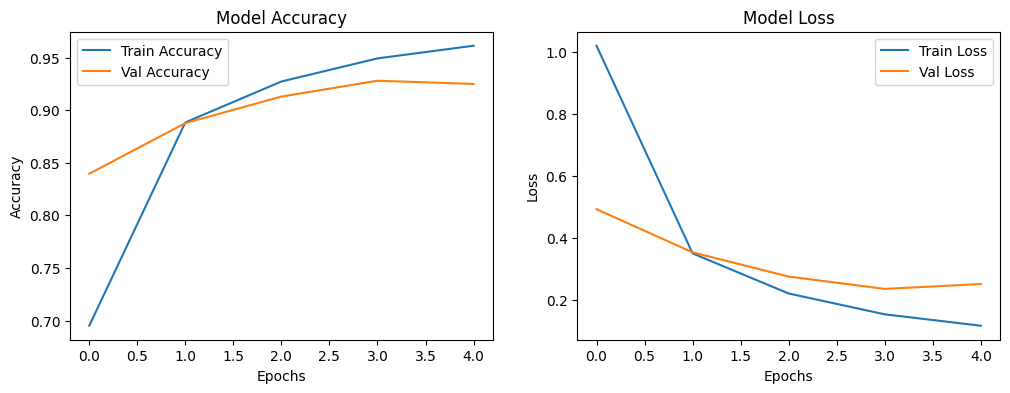


--- Model Statistics ---
Final Validation Accuracy: 92.50%
Final Validation Loss: 0.2503


In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Training vs Validation Graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy Graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss Graph
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.show()

# 2. Statistical Evaluation
print("\n--- Model Statistics ---")
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f"Final Validation Accuracy: {val_acc * 100:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")

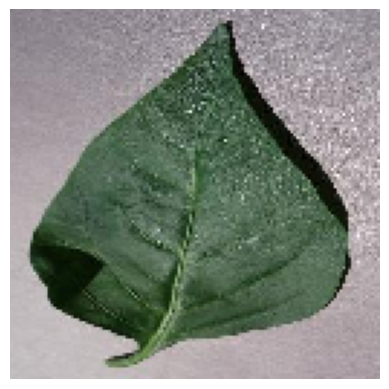

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
** Prediction:** Pepper,_bell___healthy (99.93%)
** Treatment:** Research specific agricultural guidelines for this condition.


In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob
import random

# Get the list of class names
class_names = list(train_data.class_indices.keys())

def predict_and_treat(img_path):
    # Load and display the image
    img = image.load_img(img_path, target_size=(128, 128))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Preprocess the image for the model
    img_array = image.img_to_array(img)
    img_array = opencv_preprocess(img_array) / 255.0  # Apply OpenCV & rescale
    img_array = np.expand_dims(img_array, axis=0)     # Add batch dimension

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Look up treatment (defaults to a general message if not in dictionary)
    treatment = TREATMENTS.get(
        predicted_class,
        "Research specific agricultural guidelines for this condition."
    )

    print(f"** Prediction:** {predicted_class} ({confidence:.2f}%)")
    print(f"** Treatment:** {treatment}")

# Test the function on a random validation image
valid_images = glob.glob(f"{valid_dir}/*/*.*") # Matches .jpg, .JPG, etc.
if valid_images:
    random_test_image = random.choice(valid_images)
    predict_and_treat(random_test_image)
else:
    print("No validation images found to test.")